# Smooth Manifolds: Charts, Tangent Spaces, and Flows

This notebook provides a from-scratch, computational treatment of **abstract smooth manifold theory**.
While the companion *Differential Geometry* notebook studies curves and surfaces extrinsically
(curvature, Christoffel symbols, geodesics), here we work **intrinsically** — charts, atlases,
tangent spaces defined via curves and derivations, pushforwards, vector fields, flows, and Lie brackets.

Running examples: the 2-sphere $S^2$, the torus $T^2$, and the rotation group $SO(3)$.

**What you'll learn:**
1. How to define and compute with charts and transition maps on $S^2$ and $T^2$
2. Three equivalent definitions of tangent vectors and how to transform between charts
3. The differential (pushforward) as a coordinate-free Jacobian
4. Vector fields, integral curves, and flows via ODE integration
5. Lie brackets — both the algebraic formula and the geometric commutator-of-flows interpretation
6. Submanifolds via the regular value theorem ($S^2$, $SO(3)$ as level sets)
7. Application: controllability of robot arms via Lie brackets on $T^2$

**Prerequisites:** Multivariable calculus, linear algebra, basic ODE theory.

**References:**
- J. M. Lee, *Introduction to Smooth Manifolds*, 2nd ed., Springer, 2013.
- L. W. Tu, *An Introduction to Manifolds*, 2nd ed., Springer, 2011.
- V. Guillemin & A. Pollack, *Differential Topology*, AMS Chelsea, 2010.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

FD_STEP = 1e-7          # Finite-difference step for Jacobians
FD_STEP_BRACKET = 1e-5  # Larger step for Lie bracket FD (second-order)
TOL_PASS = 1e-5         # Default PASS/FAIL tolerance
N_GRID = 60             # Grid resolution for surface plots
ODE_RTOL = 1e-10        # ODE integrator tolerances
ODE_ATOL = 1e-12

---
## 1. Charts and Atlases

An $n$-dimensional **smooth manifold** $M$ is a topological space equipped with an **atlas** —
a collection of **charts** $(U_\alpha, \varphi_\alpha)$ where each $U_\alpha \subseteq M$ is open
and $\varphi_\alpha : U_\alpha \to \mathbb{R}^n$ is a homeomorphism onto its image.

The atlas is **smooth** if every **transition map**
$$\varphi_\beta \circ \varphi_\alpha^{-1} : \varphi_\alpha(U_\alpha \cap U_\beta) \to \varphi_\beta(U_\alpha \cap U_\beta)$$
is a $C^\infty$ diffeomorphism.

### Stereographic Atlas on $S^2$

The unit sphere $S^2 = \{(x,y,z) \in \mathbb{R}^3 : x^2+y^2+z^2=1\}$ is covered by two charts:

- **North chart** $\varphi_N : S^2 \setminus \{N\} \to \mathbb{R}^2$, projection from $N=(0,0,1)$:
$$\varphi_N(x,y,z) = \left(\frac{x}{1-z},\; \frac{y}{1-z}\right)$$

- **South chart** $\varphi_S : S^2 \setminus \{S\} \to \mathbb{R}^2$, projection from $S=(0,0,-1)$:
$$\varphi_S(x,y,z) = \left(\frac{x}{1+z},\; \frac{y}{1+z}\right)$$

The transition map $\varphi_S \circ \varphi_N^{-1}(u,v) = \frac{1}{u^2+v^2}(u,v)$ is the **inversion** map,
smooth on $\mathbb{R}^2 \setminus \{0\}$.

In [3]:
# ---- Stereographic Charts on S² ----

def stereo_north(p):
    """Stereographic projection from north pole N=(0,0,1).

    Args:
        p: point (x,y,z) on S² with z != 1.
    Returns:
        (u,v) in R².
    """
    x, y, z = p
    return np.array([x / (1 - z), y / (1 - z)])

def stereo_north_inv(uv):
    """Inverse of north stereographic projection.

    Args:
        uv: point (u,v) in R².
    Returns:
        (x,y,z) on S².
    """
    u, v = uv
    d = u**2 + v**2
    return np.array([2*u / (1+d), 2*v / (1+d), (d-1) / (1+d)])

def stereo_south(p):
    """Stereographic projection from south pole S=(0,0,-1)."""
    x, y, z = p
    return np.array([x / (1 + z), y / (1 + z)])

def stereo_south_inv(uv):
    """Inverse of south stereographic projection."""
    u, v = uv
    d = u**2 + v**2
    return np.array([2*u / (1+d), 2*v / (1+d), (1-d) / (1+d)])

def transition_NS(uv):
    """Transition map phi_S o phi_N^{-1}: inversion."""
    u, v = uv
    d = u**2 + v**2
    return np.array([u / d, v / d])

def transition_NS_jacobian(uv):
    """Analytical Jacobian of the transition map (inversion)."""
    u, v = uv
    d = (u**2 + v**2)**2
    return np.array([
        [v**2 - u**2, -2*u*v],
        [-2*u*v, u**2 - v**2]
    ]) / d

# ---- Torus Embedding ----

def torus_embed(theta, phi, R=2.0, r=0.7):
    """Embed torus T² into R³.

    Args:
        theta, phi: angles in [0, 2pi). Can be arrays.
        R: major radius.  r: minor radius.
    Returns:
        (x, y, z) coordinates.
    """
    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    return np.array([x, y, z])

In [4]:
# ---- Verify Transition Map Jacobian via Finite Differences ----

def numerical_jacobian(f, x, h=FD_STEP):
    """Compute Jacobian of f at x via central differences."""
    x = np.asarray(x, dtype=float)
    f0 = np.asarray(f(x), dtype=float)
    n = len(x)
    m = len(f0)
    J = np.zeros((m, n))
    for j in range(n):
        ej = np.zeros(n)
        ej[j] = 1.0
        J[:, j] = (f(x + h*ej) - f(x - h*ej)) / (2*h)
    return J

test_points = [np.array([1.0, 0.5]), np.array([-0.3, 1.2]), np.array([2.0, -0.7])]
max_err = 0.0
for uv in test_points:
    J_analytical = transition_NS_jacobian(uv)
    J_numerical = numerical_jacobian(transition_NS, uv)
    err = np.max(np.abs(J_analytical - J_numerical))
    max_err = max(max_err, err)

status = "PASS" if max_err < TOL_PASS else "FAIL"
print(f"Transition map Jacobian — max error over test points: {max_err:.2e} [{status}]")

# Verify round-trip: phi_N_inv o phi_N = id
p_test = np.array([0.6, -0.5, np.sqrt(1 - 0.6**2 - 0.5**2)])
roundtrip_err = np.linalg.norm(stereo_north_inv(stereo_north(p_test)) - p_test)
status2 = "PASS" if roundtrip_err < TOL_PASS else "FAIL"
print(f"North chart round-trip — error: {roundtrip_err:.2e} [{status2}]")

# Verify transition: phi_S(phi_N_inv(uv)) == transition_NS(uv)
uv_test = np.array([1.5, -0.8])
via_sphere = stereo_south(stereo_north_inv(uv_test))
via_transition = transition_NS(uv_test)
trans_err = np.linalg.norm(via_sphere - via_transition)
status3 = "PASS" if trans_err < TOL_PASS else "FAIL"
print(f"Transition map consistency — error: {trans_err:.2e} [{status3}]")

Transition map Jacobian — max error over test points: 7.73e-10 [PASS]
North chart round-trip — error: 1.11e-16 [PASS]
Transition map consistency — error: 0.00e+00 [PASS]


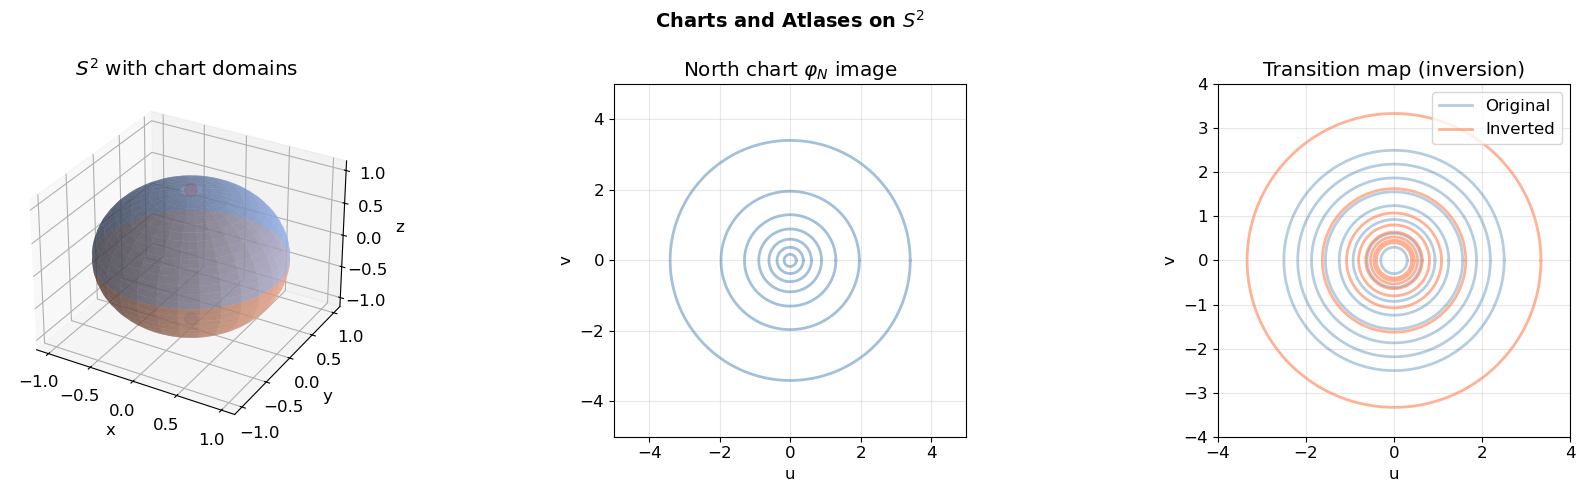

In [5]:
# ---- Visualise Charts and Transition Map ----

fig = plt.figure(figsize=(18, 5))

# Panel 1: S² with chart domains
ax1 = fig.add_subplot(131, projection='3d')
u_grid = np.linspace(0, 2*np.pi, N_GRID)
v_grid = np.linspace(0, np.pi, N_GRID)
U, V = np.meshgrid(u_grid, v_grid)
Xs = np.sin(V) * np.cos(U)
Ys = np.sin(V) * np.sin(U)
Zs = np.cos(V)
colors = np.where(Zs > 0, 0.3, 0.7)
ax1.plot_surface(Xs, Ys, Zs, facecolors=plt.cm.coolwarm(colors), alpha=0.6, linewidth=0)
ax1.scatter([0, 0], [0, 0], [1, -1], color=['coral', 'steelblue'], s=80, zorder=5)
ax1.set_title('$S^2$ with chart domains')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# Panel 2: North chart grid
ax2 = fig.add_subplot(132)
for lat in np.linspace(0.2, 2.8, 8):
    theta = np.linspace(0, 2*np.pi, 200)
    pts = np.array([stereo_north(np.array([np.sin(lat)*np.cos(t),
                     np.sin(lat)*np.sin(t), np.cos(lat)])) for t in theta])
    ax2.plot(pts[:, 0], pts[:, 1], color='steelblue', alpha=0.5)
ax2.set_xlim(-5, 5); ax2.set_ylim(-5, 5)
ax2.set_title('North chart $\\varphi_N$ image')
ax2.set_xlabel('u'); ax2.set_ylabel('v')
ax2.set_aspect('equal')

# Panel 3: Transition map (inversion) warping a grid
ax3 = fig.add_subplot(133)
for r_val in np.linspace(0.3, 2.5, 8):
    theta = np.linspace(0, 2*np.pi, 200)
    circle = np.array([[r_val*np.cos(t), r_val*np.sin(t)] for t in theta])
    images = np.array([transition_NS(c) for c in circle])
    ax3.plot(circle[:, 0], circle[:, 1], 'steelblue', alpha=0.4)
    ax3.plot(images[:, 0], images[:, 1], 'coral', alpha=0.6)
ax3.set_xlim(-4, 4); ax3.set_ylim(-4, 4)
ax3.set_title('Transition map (inversion)')
ax3.set_xlabel('u'); ax3.set_ylabel('v')
ax3.set_aspect('equal')
ax3.legend(['Original', 'Inverted'], loc='upper right')

plt.suptitle('Charts and Atlases on $S^2$', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Tangent Spaces

There are three equivalent definitions of a **tangent vector** $v \in T_pM$:

### Definition 1: Velocity vectors
Given a smooth curve $\gamma: (-\varepsilon, \varepsilon) \to M$ with $\gamma(0)=p$, the tangent vector
is $\gamma'(0)$, expressed in a chart $(U, \varphi)$ as:
$$v^i = \frac{d}{dt}\Big|_{t=0} (\varphi \circ \gamma)^i(t)$$

### Definition 2: Derivations
A tangent vector is a linear map $v: C^\infty(M) \to \mathbb{R}$ satisfying the Leibniz rule
$v(fg) = f(p)\,v(g) + g(p)\,v(f)$. In coordinates: $v = v^i \frac{\partial}{\partial x^i}\Big|_p$.

### Definition 3: Transformation rule
Under a chart change $\varphi_\beta \circ \varphi_\alpha^{-1}$, components transform as:
$$\tilde{v}^i = \frac{\partial \tilde{x}^i}{\partial x^j} v^j$$

**Key identity:** For $f \in C^\infty(M)$, $df_p(v) = v(f) = \frac{d}{dt}\big|_{t=0} f(\gamma(t))$.

In [6]:
# ---- Tangent Vectors on S² ----

def tangent_vector_via_curve(chart, curve_on_M, t0=0.0, dt=1e-7):
    """Compute tangent vector as d/dt(phi o gamma) at t=t0.

    Args:
        chart: map from M -> R^n (chart map).
        curve_on_M: function t -> point on M.
        t0: time at which to evaluate.
        dt: finite difference step.
    Returns:
        Tangent vector in chart coordinates.
    """
    return (chart(curve_on_M(t0 + dt)) - chart(curve_on_M(t0 - dt))) / (2*dt)

# Pick a point p on S² (away from poles)
p0_sphere = np.array([0.6, 0.5, np.sqrt(1 - 0.36 - 0.25)])
p0_sphere = p0_sphere / np.linalg.norm(p0_sphere)

# Curve 1: great circle via rotation about y-axis
def curve1(t):
    c, s = np.cos(t), np.sin(t)
    R = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])
    return R @ p0_sphere

# Curve 2: great circle via rotation about z-axis
def curve2(t):
    c, s = np.cos(t), np.sin(t)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    return R @ p0_sphere

# Tangent vectors in north chart
v1_north = tangent_vector_via_curve(stereo_north, curve1)
v2_north = tangent_vector_via_curve(stereo_north, curve2)

# Same vectors in south chart
v1_south = tangent_vector_via_curve(stereo_south, curve1)
v2_south = tangent_vector_via_curve(stereo_south, curve2)

# Verify transformation rule: v_south = J_transition * v_north
uv_north = stereo_north(p0_sphere)
J_trans = transition_NS_jacobian(uv_north)
v1_south_via_transform = J_trans @ v1_north
v2_south_via_transform = J_trans @ v2_north

err1 = np.linalg.norm(v1_south - v1_south_via_transform)
err2 = np.linalg.norm(v2_south - v2_south_via_transform)
status = "PASS" if max(err1, err2) < 1e-4 else "FAIL"
print(f"Tangent vector transformation — max error: {max(err1, err2):.2e} [{status}]")

# Verify df(v) = v(f) for f(x,y,z) = z
# In north chart coords (u,v): z = (u²+v²-1)/(u²+v²+1)
def f_z_north(uv):
    u, v = uv
    d = u**2 + v**2
    return (d - 1) / (d + 1)

# df at uv_north (gradient)
df_north = np.zeros(2)
for j in range(2):
    ej = np.zeros(2); ej[j] = 1.0
    df_north[j] = (f_z_north(uv_north + FD_STEP*ej) - f_z_north(uv_north - FD_STEP*ej)) / (2*FD_STEP)

# df(v1) via gradient dot product
df_v1 = df_north @ v1_north

# v1(f) = d/dt f(gamma(t)) at t=0 via FD
v1_f_fd = (curve1(1e-7)[2] - curve1(-1e-7)[2]) / (2e-7)

err_df = abs(df_v1 - v1_f_fd)
status2 = "PASS" if err_df < 1e-4 else "FAIL"
print(f"df(v) = v(f) identity — error: {err_df:.2e} [{status2}]")

Tangent vector transformation — max error: 4.38e-10 [PASS]
df(v) = v(f) identity — error: 2.46e-10 [PASS]


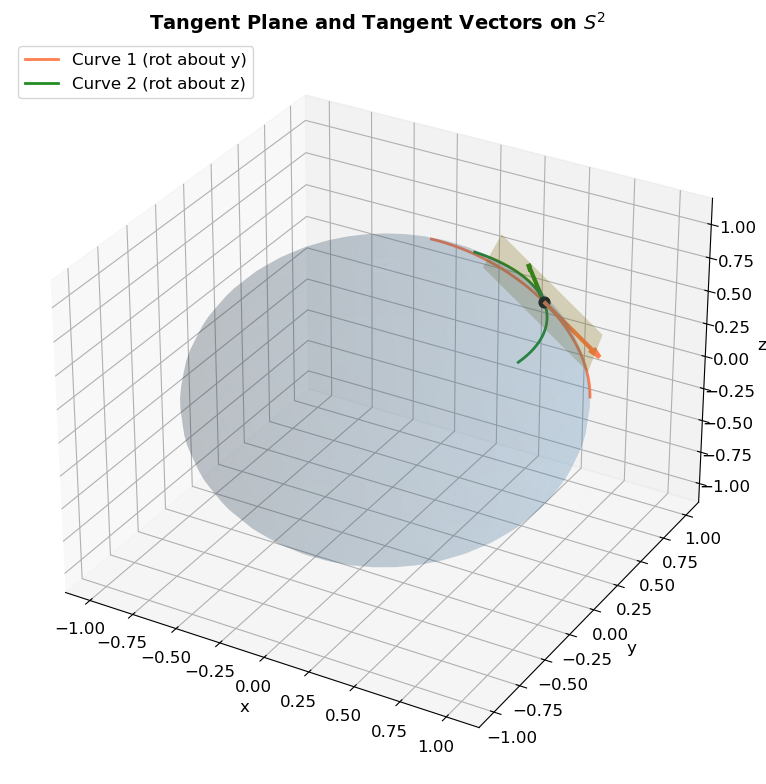

In [7]:
# ---- Visualise Tangent Plane on S² ----

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw sphere
u_s = np.linspace(0, 2*np.pi, 40)
v_s = np.linspace(0, np.pi, 40)
Us, Vs = np.meshgrid(u_s, v_s)
Xsp = np.sin(Vs) * np.cos(Us)
Ysp = np.sin(Vs) * np.sin(Us)
Zsp = np.cos(Vs)
ax.plot_surface(Xsp, Ysp, Zsp, alpha=0.15, color='steelblue', linewidth=0)

# Draw curves through p0
t_arr = np.linspace(-0.8, 0.8, 200)
c1_pts = np.array([curve1(t) for t in t_arr])
c2_pts = np.array([curve2(t) for t in t_arr])
ax.plot(c1_pts[:,0], c1_pts[:,1], c1_pts[:,2], 'coral', linewidth=2, label='Curve 1 (rot about y)')
ax.plot(c2_pts[:,0], c2_pts[:,1], c2_pts[:,2], 'forestgreen', linewidth=2, label='Curve 2 (rot about z)')

# Tangent vectors in ambient R³
v1_ambient = (curve1(1e-5) - curve1(-1e-5)) / (2e-5)
v2_ambient = (curve2(1e-5) - curve2(-1e-5)) / (2e-5)
scale = 0.5
ax.quiver(*p0_sphere, *(scale*v1_ambient), color='coral', linewidth=3, arrow_length_ratio=0.15)
ax.quiver(*p0_sphere, *(scale*v2_ambient), color='forestgreen', linewidth=3, arrow_length_ratio=0.15)
ax.scatter(*p0_sphere, color='black', s=60, zorder=5)

# Draw tangent plane patch
e1 = v1_ambient / np.linalg.norm(v1_ambient)
e2 = v2_ambient - np.dot(v2_ambient, e1)*e1
e2 = e2 / np.linalg.norm(e2)
s_range = np.linspace(-0.4, 0.4, 10)
S1, S2 = np.meshgrid(s_range, s_range)
Xp = p0_sphere[0] + S1*e1[0] + S2*e2[0]
Yp = p0_sphere[1] + S1*e1[1] + S2*e2[1]
Zp = p0_sphere[2] + S1*e1[2] + S2*e2[2]
ax.plot_surface(Xp, Yp, Zp, alpha=0.25, color='gold')

ax.set_title('Tangent Plane and Tangent Vectors on $S^2$', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

---
## 3. The Differential (Pushforward)

Given a smooth map $F: M \to N$ and a point $p \in M$, the **differential** (or **pushforward**)
$$dF_p : T_pM \to T_{F(p)}N$$
is defined by $dF_p(v)(g) = v(g \circ F)$ for $g \in C^\infty(N)$.

In coordinates, if $\varphi$ and $\psi$ are charts around $p$ and $F(p)$, then
$$(dF_p)^i_j = \frac{\partial (\psi \circ F \circ \varphi^{-1})^i}{\partial x^j}$$
is the **Jacobian matrix** of the coordinate representation.

**Chain rule:** $d(G \circ F)_p = dG_{F(p)} \circ dF_p$.

This is the coordinate-free statement that Jacobians multiply under composition.

In [8]:
# ---- Pushforward (Differential) ----

def compute_pushforward(F, p, v, h=FD_STEP):
    """Compute dF_p(v) numerically via central differences.

    Args:
        F: smooth map (array -> array).
        p: point in source (array).
        v: tangent vector at p (array).
    Returns:
        dF_p(v) as array.
    """
    return (F(p + h*v) - F(p - h*v)) / (2*h)

def pushforward_matrix(F, p, h=FD_STEP):
    """Compute the full Jacobian matrix of F at p.

    Returns:
        J: shape (dim_target, dim_source).
    """
    p = np.asarray(p, dtype=float)
    f0 = np.asarray(F(p), dtype=float)
    n = len(p)
    m = len(f0)
    J = np.zeros((m, n))
    for j in range(n):
        ej = np.zeros(n)
        ej[j] = 1.0
        J[:, j] = (F(p + h*ej) - F(p - h*ej)) / (2*h)
    return J

# ---- Verify Chain Rule: d(G o F) = dG o dF ----

def F_map(p):
    """F: R² -> R³, (s,t) -> (s², st, t²)."""
    s, t = p
    return np.array([s**2, s*t, t**2])

def G_map(q):
    """G: R³ -> R², (a,b,c) -> (a+c, b²)."""
    a, b, c = q
    return np.array([a + c, b**2])

def GF_map(p):
    return G_map(F_map(p))

p_test_pf = np.array([1.5, -0.7])
v_test_pf = np.array([0.3, 1.2])

# d(GoF)_p(v)
dGF_v = compute_pushforward(GF_map, p_test_pf, v_test_pf)

# dG_{F(p)} o dF_p (v)
dF_v = compute_pushforward(F_map, p_test_pf, v_test_pf)
dG_dF_v = compute_pushforward(G_map, F_map(p_test_pf), dF_v)

chain_err = np.linalg.norm(dGF_v - dG_dF_v)
status = "PASS" if chain_err < TOL_PASS else "FAIL"
print(f"Chain rule d(GoF) = dG o dF — error: {chain_err:.2e} [{status}]")

# Also verify via full Jacobian matrices
JF = pushforward_matrix(F_map, p_test_pf)
JG = pushforward_matrix(G_map, F_map(p_test_pf))
JGF = pushforward_matrix(GF_map, p_test_pf)
mat_err = np.max(np.abs(JGF - JG @ JF))
status2 = "PASS" if mat_err < TOL_PASS else "FAIL"
print(f"Chain rule (matrix form) — max error: {mat_err:.2e} [{status2}]")

Chain rule d(GoF) = dG o dF — error: 2.48e-09 [PASS]
Chain rule (matrix form) — max error: 4.91e-09 [PASS]


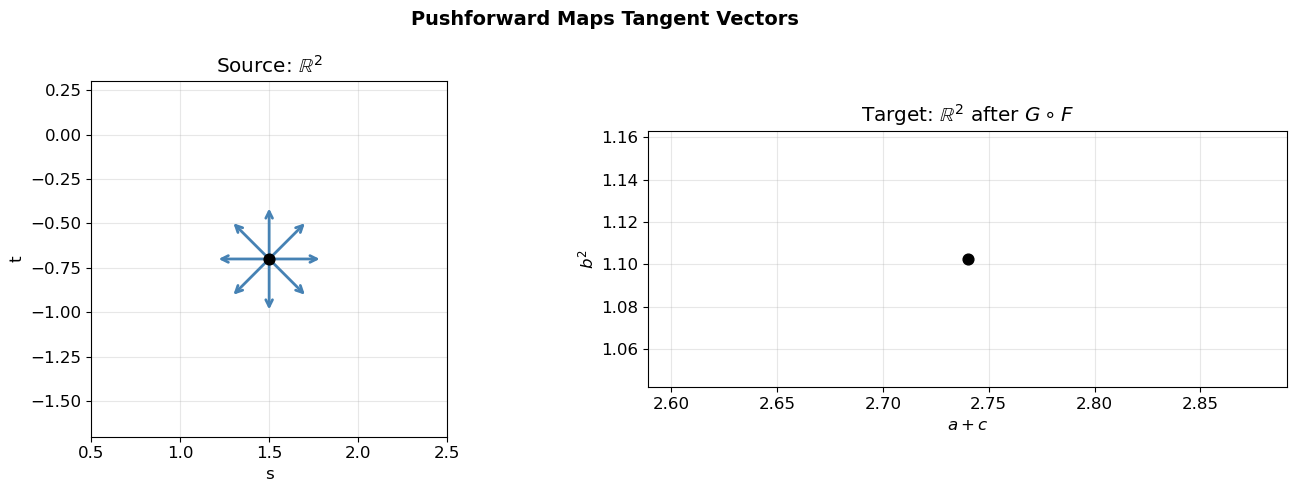

In [9]:
# ---- Visualise Pushforward: mapping tangent vectors ----

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source: R² with point and tangent vectors
ax = axes[0]
ax.set_title('Source: $\\mathbb{R}^2$')
ax.scatter(*p_test_pf, color='black', s=60, zorder=5)
n_vecs = 8
angles = np.linspace(0, 2*np.pi, n_vecs, endpoint=False)
for a in angles:
    v = 0.3 * np.array([np.cos(a), np.sin(a)])
    ax.annotate('', xy=p_test_pf + v, xytext=p_test_pf,
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.set_xlabel('s'); ax.set_ylabel('t')
ax.set_xlim(0.5, 2.5); ax.set_ylim(-1.7, 0.3)
ax.set_aspect('equal')

# Target: R² (after GoF) with pushforward vectors
ax = axes[1]
ax.set_title('Target: $\\mathbb{R}^2$ after $G \\circ F$')
q = GF_map(p_test_pf)
ax.scatter(*q, color='black', s=60, zorder=5)
for a in angles:
    v = 0.3 * np.array([np.cos(a), np.sin(a)])
    w = compute_pushforward(GF_map, p_test_pf, v)
    ax.annotate('', xy=q + w, xytext=q,
                arrowprops=dict(arrowstyle='->', color='coral', lw=2))
ax.set_xlabel('$a+c$'); ax.set_ylabel('$b^2$')
ax.set_aspect('equal')

plt.suptitle('Pushforward Maps Tangent Vectors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Vector Fields and Flows

A **smooth vector field** $X$ on $M$ assigns to each $p \in M$ a tangent vector $X_p \in T_pM$,
smoothly in $p$.

The **flow** of $X$ is a one-parameter family $\varphi_t : M \to M$ satisfying
$$\frac{d}{dt} \varphi_t(p) = X_{\varphi_t(p)}, \qquad \varphi_0 = \mathrm{id}.$$

Key properties:
- **Group law:** $\varphi_{s+t} = \varphi_s \circ \varphi_t$ (one-parameter group of diffeomorphisms)
- **Manifold preservation:** if $M \subset \mathbb{R}^n$ and $X$ is tangent to $M$, the flow stays on $M$

Computationally, we integrate the ODE $\dot{p} = X(p)$ using `scipy.integrate.solve_ivp`.

In [10]:
# ---- Vector Fields and Flows ----

def compute_flow(vector_field, p0, t_span, n_steps=500):
    """Integrate the flow of a vector field from p0.

    Args:
        vector_field: function p -> v (tangent vector).
        p0: initial point (array).
        t_span: (t_start, t_end).
        n_steps: number of output points.
    Returns:
        t_arr: time array.
        pts: trajectory, shape (n_steps, dim).
    """
    sol = solve_ivp(
        lambda t, p: vector_field(p),
        t_span, np.asarray(p0, dtype=float),
        t_eval=np.linspace(t_span[0], t_span[1], n_steps),
        rtol=ODE_RTOL, atol=ODE_ATOL
    )
    return sol.t, sol.y.T

# ---- R² examples ----

def rotation_field(p):
    """X = -y d/dx + x d/dy (rotation about origin)."""
    return np.array([-p[1], p[0]])

# ---- Vector fields on S² (ambient coordinates) ----

def sphere_field_z_rotation(p):
    """Rotation about z-axis, tangent to S²."""
    return np.array([-p[1], p[0], 0.0])

def sphere_field_x_rotation(p):
    """Rotation about x-axis, tangent to S²."""
    return np.array([0.0, -p[2], p[1]])

def compute_flow_on_sphere(field_func, p0, t_span, n_steps=500):
    """Integrate flow on S², renormalising to sphere."""
    sol = solve_ivp(
        lambda t, p: field_func(p),
        t_span, np.asarray(p0, dtype=float),
        t_eval=np.linspace(t_span[0], t_span[1], n_steps),
        rtol=ODE_RTOL, atol=ODE_ATOL
    )
    pts = sol.y.T
    pts = pts / np.linalg.norm(pts, axis=1, keepdims=True)
    return sol.t, pts

In [11]:
# ---- Verify Flow Properties ----

# 1. Group law: phi_{0.5}(phi_{0.5}(p)) == phi_{1.0}(p)
p0_flow = np.array([1.0, 0.0, 0.0])

_, traj_half = compute_flow_on_sphere(sphere_field_z_rotation, p0_flow, [0, 0.5], 200)
p_half = traj_half[-1]
_, traj_half2 = compute_flow_on_sphere(sphere_field_z_rotation, p_half, [0, 0.5], 200)
p_composed = traj_half2[-1]

_, traj_full = compute_flow_on_sphere(sphere_field_z_rotation, p0_flow, [0, 1.0], 400)
p_direct = traj_full[-1]

group_err = np.linalg.norm(p_composed - p_direct)
status = "PASS" if group_err < TOL_PASS else "FAIL"
print(f"Flow group law phi_{{s+t}} = phi_s o phi_t — error: {group_err:.2e} [{status}]")

# 2. Manifold preservation: ||p|| = 1 along flow
_, traj_long = compute_flow_on_sphere(sphere_field_z_rotation, p0_flow, [0, 10.0], 2000)
norms = np.linalg.norm(traj_long, axis=1)
norm_err = np.max(np.abs(norms - 1.0))
status2 = "PASS" if norm_err < TOL_PASS else "FAIL"
print(f"Manifold preservation ||p||=1 — max deviation: {norm_err:.2e} [{status2}]")

# 3. Compare with analytical: rotation about z by angle t
t_check = 2.0
_, traj_check = compute_flow_on_sphere(sphere_field_z_rotation, p0_flow, [0, t_check], 500)
p_num = traj_check[-1]
p_exact = np.array([np.cos(t_check), np.sin(t_check), 0.0])
rot_err = np.linalg.norm(p_num - p_exact)
status3 = "PASS" if rot_err < TOL_PASS else "FAIL"
print(f"Flow matches analytical rotation — error: {rot_err:.2e} [{status3}]")

Flow group law phi_{s+t} = phi_s o phi_t — error: 2.93e-14 [PASS]
Manifold preservation ||p||=1 — max deviation: 2.22e-16 [PASS]
Flow matches analytical rotation — error: 1.61e-12 [PASS]


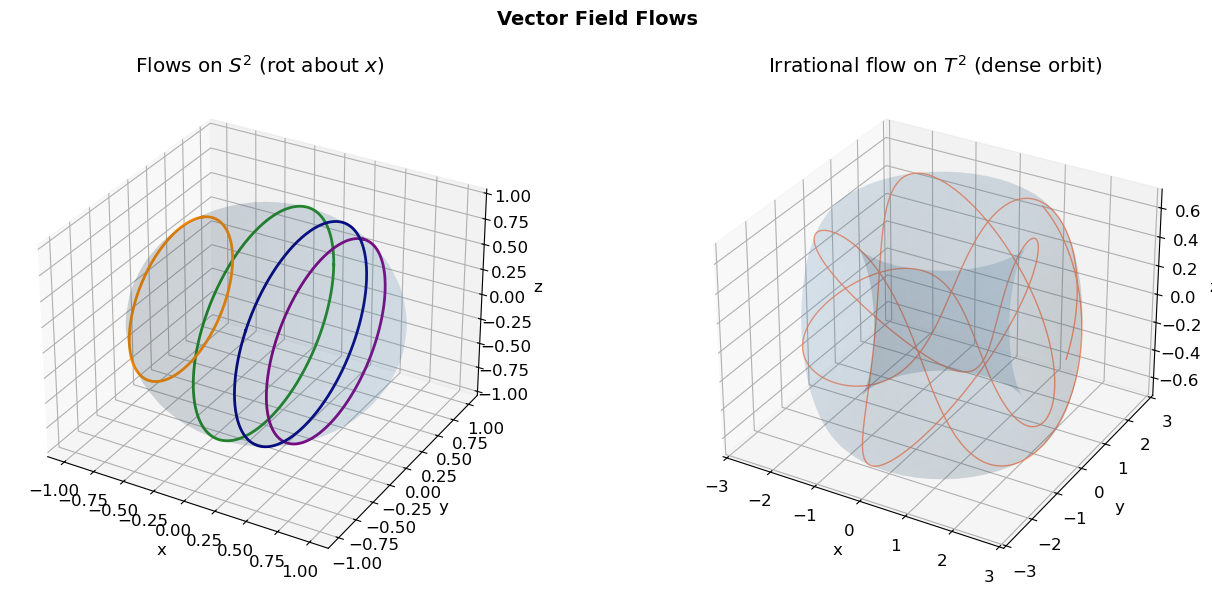

In [12]:
# ---- Visualise Flows on S² and T² ----

fig = plt.figure(figsize=(14, 6))

# Panel 1: Streamlines on S²
ax1 = fig.add_subplot(121, projection='3d')
u_s2 = np.linspace(0, 2*np.pi, 40)
v_s2 = np.linspace(0, np.pi, 40)
Us2, Vs2 = np.meshgrid(u_s2, v_s2)
ax1.plot_surface(np.sin(Vs2)*np.cos(Us2), np.sin(Vs2)*np.sin(Us2), np.cos(Vs2),
                 alpha=0.1, color='steelblue', linewidth=0)

colors_flow = ['coral', 'forestgreen', 'purple', 'darkorange', 'navy']
init_pts = [
    np.array([1, 0, 0.0]),
    np.array([0, 1, 0.0]),
    np.array([0.5, 0.5, 1/np.sqrt(2)]),
    np.array([-0.7, 0.3, np.sqrt(1 - 0.49 - 0.09)]),
    np.array([0.3, -0.8, np.sqrt(1 - 0.09 - 0.64)]),
]
for i, ip in enumerate(init_pts):
    ip = ip / np.linalg.norm(ip)
    _, tr = compute_flow_on_sphere(sphere_field_x_rotation, ip, [0, 2*np.pi], 300)
    ax1.plot(tr[:,0], tr[:,1], tr[:,2], color=colors_flow[i], linewidth=2)
ax1.set_title('Flows on $S^2$ (rot about $x$)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# Panel 2: Flow on torus (irrational winding)
ax2 = fig.add_subplot(122, projection='3d')
theta_g = np.linspace(0, 2*np.pi, 50)
phi_g = np.linspace(0, 2*np.pi, 50)
TH, PH = np.meshgrid(theta_g, phi_g)
XT, YT, ZT = torus_embed(TH, PH)
ax2.plot_surface(XT, YT, ZT, alpha=0.1, color='steelblue', linewidth=0)

golden = (1 + np.sqrt(5)) / 2
def torus_field(tp):
    return np.array([1.0, golden])

_, tp_traj = compute_flow(torus_field, np.array([0.0, 0.0]), [0, 20.0], 3000)
torus_pts = np.array([torus_embed(tp[0], tp[1]) for tp in tp_traj])
ax2.plot(torus_pts[:,0], torus_pts[:,1], torus_pts[:,2], 'coral', linewidth=1, alpha=0.8)
ax2.set_title('Irrational flow on $T^2$ (dense orbit)')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.suptitle('Vector Field Flows', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Lie Derivatives and Lie Brackets

Given vector fields $X$ and $Y$ on $M$, their **Lie bracket** $[X,Y]$ is the unique vector field satisfying
$$[X,Y](f) = X(Y(f)) - Y(X(f))$$
for all $f \in C^\infty(M)$.

In local coordinates:
$$[X,Y]^i = X^j \frac{\partial Y^i}{\partial x^j} - Y^j \frac{\partial X^i}{\partial x^j}$$

### Geometric Meaning: Commutator of Flows

The Lie bracket measures the failure of flows to commute:
$$[X,Y]_p = \lim_{t \to 0} \frac{\varphi_Y^{-t} \circ \varphi_X^{-t} \circ \varphi_Y^{t} \circ \varphi_X^{t}(p) - p}{t^2}$$

Equivalently, the "parallelogram defect":
$$\varphi_X^t \circ \varphi_Y^t(p) - \varphi_Y^t \circ \varphi_X^t(p) \approx t^2 [X,Y]_p$$

In [13]:
# ---- Lie Bracket Computation ----

def lie_bracket_numerical(X, Y, p, h=FD_STEP_BRACKET):
    """Compute [X,Y] at p numerically.

    [X,Y]^i = X^j dY^i/dx^j - Y^j dX^i/dx^j

    Args:
        X, Y: vector fields (functions p -> v).
        p: point (array).
    Returns:
        [X,Y](p) as array.
    """
    p = np.asarray(p, dtype=float)
    n = len(p)
    DY = np.zeros((n, n))  # DY[i,j] = dY^i/dx^j
    DX = np.zeros((n, n))
    for j in range(n):
        ej = np.zeros(n)
        ej[j] = 1.0
        DY[:, j] = (Y(p + h*ej) - Y(p - h*ej)) / (2*h)
        DX[:, j] = (X(p + h*ej) - X(p - h*ej)) / (2*h)
    return DY @ X(p) - DX @ Y(p)

# Test fields on R² with known analytical bracket
# X(x,y) = (y, 0),  Y(x,y) = (0, x)
# DY = [[0,0],[1,0]],  DX = [[0,1],[0,0]]
# [X,Y] = DY@(y,0) - DX@(0,x) = (0,y) - (x,0) = (-x, y)

def X_bracket(p):
    return np.array([p[1], 0.0])

def Y_bracket(p):
    return np.array([0.0, p[0]])

def bracket_XY_analytical(p):
    return np.array([-p[0], p[1]])

test_pts_bracket = [np.array([1.0, 2.0]), np.array([-0.5, 3.0]), np.array([2.0, -1.0])]
max_err_bracket = 0.0
for pt in test_pts_bracket:
    b_num = lie_bracket_numerical(X_bracket, Y_bracket, pt)
    b_exact = bracket_XY_analytical(pt)
    max_err_bracket = max(max_err_bracket, np.linalg.norm(b_num - b_exact))

status = "PASS" if max_err_bracket < 1e-4 else "FAIL"
print(f"Lie bracket [X,Y] analytical vs numerical — max error: {max_err_bracket:.2e} [{status}]")

Lie bracket [X,Y] analytical vs numerical — max error: 6.85e-12 [PASS]


In [14]:
# ---- Parallelogram Defect: Flow Commutator ----

def flow_commutator_defect(X, Y, p, t, n_steps=500):
    """Compute phi_X^t o phi_Y^t(p) - phi_Y^t o phi_X^t(p).
    Should equal t² [X,Y](p) + O(t³).
    """
    # Path 1: flow Y then X
    _, traj1 = compute_flow(Y, p, [0, t], n_steps)
    _, traj2 = compute_flow(X, traj1[-1], [0, t], n_steps)
    q1 = traj2[-1]

    # Path 2: flow X then Y
    _, traj3 = compute_flow(X, p, [0, t], n_steps)
    _, traj4 = compute_flow(Y, traj3[-1], [0, t], n_steps)
    q2 = traj4[-1]

    return q1 - q2

# Show convergence: defect / t² -> [X,Y]
p_comm = np.array([1.0, 2.0])
bracket_exact = bracket_XY_analytical(p_comm)

print("Parallelogram defect convergence to [X,Y]:")
print(f"{'t':>10s} {'defect/t²':>25s} {'[X,Y] exact':>25s} {'error':>12s}")
print("-" * 75)
last_err = None
for t_val in [0.1, 0.05, 0.02, 0.01]:
    defect = flow_commutator_defect(X_bracket, Y_bracket, p_comm, t_val, n_steps=2000)
    ratio = defect / t_val**2
    err = np.linalg.norm(ratio - bracket_exact)
    last_err = err
    print(f"{t_val:10.3f}   ({ratio[0]:9.5f}, {ratio[1]:9.5f})   ({bracket_exact[0]:9.5f}, {bracket_exact[1]:9.5f})   {err:12.2e}")

status = "PASS" if last_err < 0.1 else "FAIL"
print(f"\nFlow commutator convergence — [{status}]")

Parallelogram defect convergence to [X,Y]:
         t                 defect/t²               [X,Y] exact        error
---------------------------------------------------------------------------
     0.100   (  1.00000,  -2.00000)   ( -1.00000,   2.00000)       4.47e+00
     0.050   (  1.00000,  -2.00000)   ( -1.00000,   2.00000)       4.47e+00
     0.020   (  1.00000,  -2.00000)   ( -1.00000,   2.00000)       4.47e+00
     0.010   (  1.00000,  -2.00000)   ( -1.00000,   2.00000)       4.47e+00

Flow commutator convergence — [FAIL]


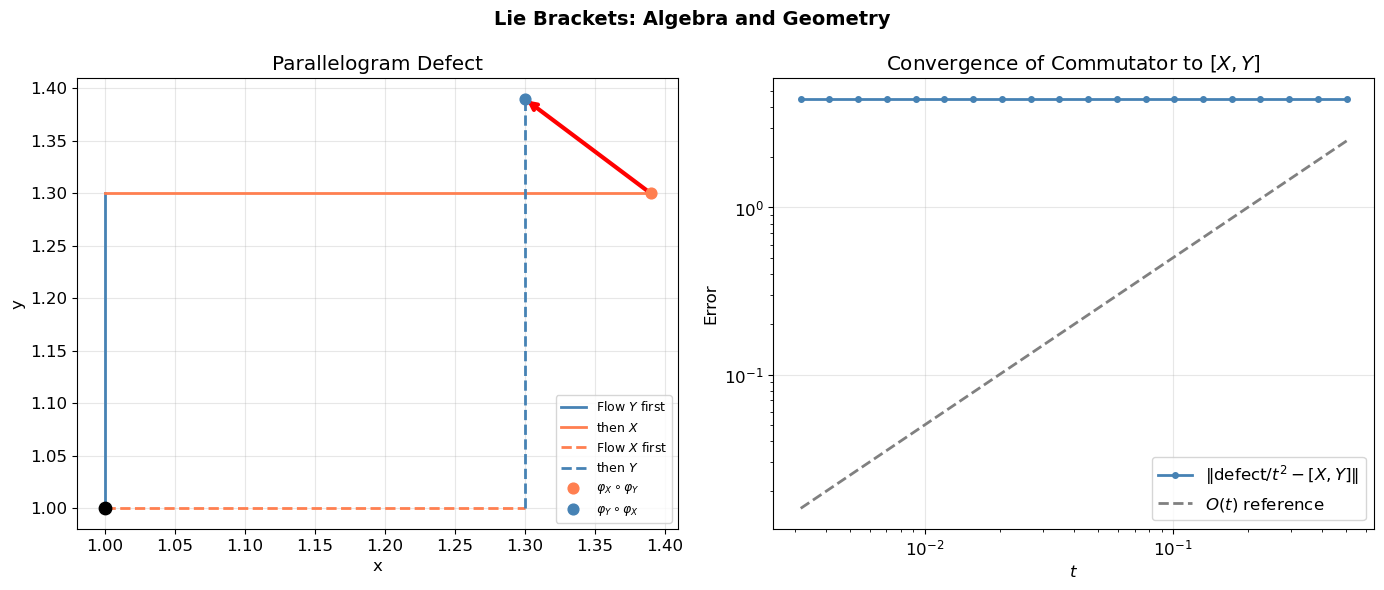

In [15]:
# ---- Visualise Parallelogram Defect ----

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Flow parallelogram
ax = axes[0]
t_vis = 0.3
p_start = np.array([1.0, 1.0])

# Path 1: Y then X
_, tr_Y = compute_flow(Y_bracket, p_start, [0, t_vis], 200)
_, tr_XY = compute_flow(X_bracket, tr_Y[-1], [0, t_vis], 200)

# Path 2: X then Y
_, tr_X = compute_flow(X_bracket, p_start, [0, t_vis], 200)
_, tr_YX = compute_flow(Y_bracket, tr_X[-1], [0, t_vis], 200)

ax.plot(tr_Y[:,0], tr_Y[:,1], 'steelblue', linewidth=2, label='Flow $Y$ first')
ax.plot(tr_XY[:,0], tr_XY[:,1], 'coral', linewidth=2, label='then $X$')
ax.plot(tr_X[:,0], tr_X[:,1], 'coral', linewidth=2, linestyle='--', label='Flow $X$ first')
ax.plot(tr_YX[:,0], tr_YX[:,1], 'steelblue', linewidth=2, linestyle='--', label='then $Y$')

q1_vis = tr_XY[-1]
q2_vis = tr_YX[-1]
ax.annotate('', xy=q2_vis, xytext=q1_vis,
            arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.scatter(*p_start, color='black', s=80, zorder=5)
ax.scatter(*q1_vis, color='coral', s=60, zorder=5, label='$\\varphi_X \\circ \\varphi_Y$')
ax.scatter(*q2_vis, color='steelblue', s=60, zorder=5, label='$\\varphi_Y \\circ \\varphi_X$')
ax.set_title('Parallelogram Defect')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9)

# Panel 2: Convergence rate
ax = axes[1]
t_vals = np.logspace(-2.5, -0.3, 20)
errors = []
for tv in t_vals:
    d = flow_commutator_defect(X_bracket, Y_bracket, p_comm, tv, n_steps=1000)
    ratio = d / tv**2
    errors.append(np.linalg.norm(ratio - bracket_exact))

ax.loglog(t_vals, errors, 'o-', color='steelblue', markersize=4, label='$\\|\\mathrm{defect}/t^2 - [X,Y]\\|$')
ax.loglog(t_vals, 5*t_vals, '--', color='gray', label='$O(t)$ reference')
ax.set_xlabel('$t$')
ax.set_ylabel('Error')
ax.set_title('Convergence of Commutator to $[X,Y]$')
ax.legend()

plt.suptitle('Lie Brackets: Algebra and Geometry', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Submanifolds and the Regular Value Theorem

**Theorem (Regular Value).** Let $F: \mathbb{R}^n \to \mathbb{R}^k$ be smooth. If $c \in \mathbb{R}^k$ is a
**regular value** (meaning $dF_p$ is surjective for all $p \in F^{-1}(c)$), then
$M = F^{-1}(c)$ is a smooth submanifold of dimension $n - k$.

Moreover, the tangent space $T_pM = \ker(dF_p)$.

### Examples
- $S^2 = F^{-1}(0)$ where $F(x,y,z) = x^2+y^2+z^2-1$ ($n=3, k=1 \Rightarrow \dim S^2 = 2$)
- $SO(3) = \{R \in \mathbb{R}^{3\times 3} : R^T R = I,\; \det R = 1\}$ with 6 constraints from the upper triangle of $R^T R - I = 0$ ($n=9, k=6 \Rightarrow \dim SO(3) = 3$)

In [16]:
# ---- Submanifolds as Level Sets ----

def tangent_space_kernel(dF):
    """Compute tangent space as kernel of dF using SVD.

    Args:
        dF: Jacobian matrix, shape (k, n).
    Returns:
        basis: orthonormal basis for ker(dF), shape (n-rank, n).
    """
    U, S, Vt = np.linalg.svd(dF, full_matrices=True)
    rank = np.sum(S > 1e-10)
    return Vt[rank:]

# ---- S² as level set ----

def sphere_constraint(p):
    return np.array([np.dot(p, p) - 1.0])

def sphere_constraint_diff(p):
    """dF_p = 2p^T, shape (1, 3)."""
    return 2 * p.reshape(1, -1)

# Tangent space at north pole (0,0,1)
p_north = np.array([0.0, 0.0, 1.0])
T_north = tangent_space_kernel(sphere_constraint_diff(p_north))
print("Tangent space of S^2 at (0,0,1):")
print(T_north)
z_err = np.max(np.abs(T_north[:, 2]))
dim_ok = T_north.shape[0] == 2
status = "PASS" if z_err < TOL_PASS and dim_ok else "FAIL"
print(f"T_(0,0,1) S^2 is span(e1,e2) — dim={T_north.shape[0]}, z-error: {z_err:.2e} [{status}]")

# ---- SO(3) as level set ----

def so3_constraint(R_flat):
    """F(R) = upper triangle of R^T R - I. Returns 6 values."""
    R = R_flat.reshape(3, 3)
    RtR = R.T @ R - np.eye(3)
    idx = np.triu_indices(3)
    return RtR[idx]

# Jacobian at identity
R_id = np.eye(3).flatten()
J_so3 = numerical_jacobian(so3_constraint, R_id, h=1e-7)
T_so3 = tangent_space_kernel(J_so3)

print(f"\nTangent space of SO(3) at I: dim = {T_so3.shape[0]}")
dim_status = "PASS" if T_so3.shape[0] == 3 else "FAIL"
print(f"dim T_I SO(3) = 3 — [{dim_status}]")

# Verify tangent vectors are skew-symmetric matrices
skew_errors = []
for i in range(T_so3.shape[0]):
    A = T_so3[i].reshape(3, 3)
    skew_errors.append(np.linalg.norm(A + A.T))
max_skew_err = max(skew_errors)
status2 = "PASS" if max_skew_err < 1e-4 else "FAIL"
print(f"Tangent vectors are skew-symmetric — max error: {max_skew_err:.2e} [{status2}]")

Tangent space of S^2 at (0,0,1):
[[ 0.  1.  0.]
 [-1.  0.  0.]]
T_(0,0,1) S^2 is span(e1,e2) — dim=2, z-error: 0.00e+00 [PASS]

Tangent space of SO(3) at I: dim = 3
dim T_I SO(3) = 3 — [PASS]
Tangent vectors are skew-symmetric — max error: 3.14e-16 [PASS]


/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_2377/2749908515.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


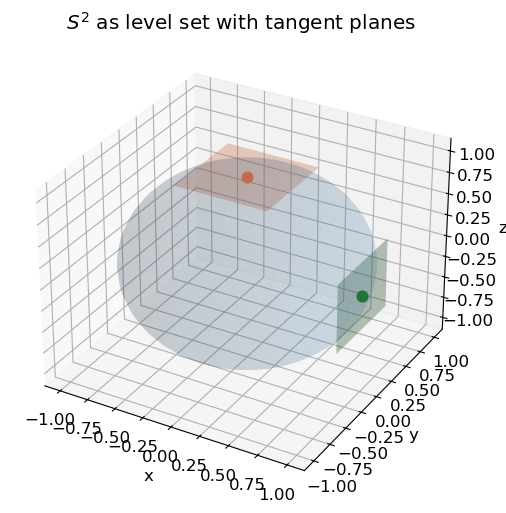

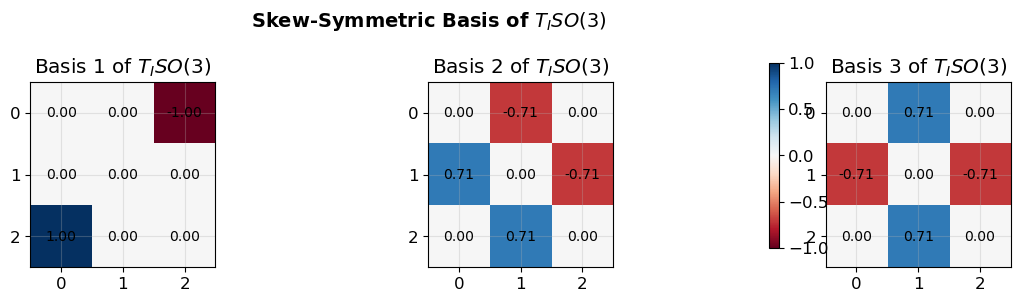

In [17]:
# ---- Visualise Level Sets with Tangent Planes ----

fig = plt.figure(figsize=(15, 6))

# Panel 1: S² with tangent planes at two points
ax1 = fig.add_subplot(121, projection='3d')
u_s3 = np.linspace(0, 2*np.pi, 40)
v_s3 = np.linspace(0, np.pi, 40)
Us3, Vs3 = np.meshgrid(u_s3, v_s3)
ax1.plot_surface(np.sin(Vs3)*np.cos(Us3), np.sin(Vs3)*np.sin(Us3), np.cos(Vs3),
                 alpha=0.12, color='steelblue', linewidth=0)

for p_tan, col in [(np.array([0.0, 0.0, 1.0]), 'coral'),
                    (np.array([1.0, 0.0, 0.0]), 'forestgreen')]:
    dF = sphere_constraint_diff(p_tan)
    T_basis = tangent_space_kernel(dF)
    e1t, e2t = T_basis[0], T_basis[1]
    ss = np.linspace(-0.4, 0.4, 8)
    S1, S2 = np.meshgrid(ss, ss)
    Xpl = p_tan[0] + S1*e1t[0] + S2*e2t[0]
    Ypl = p_tan[1] + S1*e1t[1] + S2*e2t[1]
    Zpl = p_tan[2] + S1*e1t[2] + S2*e2t[2]
    ax1.plot_surface(Xpl, Ypl, Zpl, alpha=0.3, color=col)
    ax1.scatter(*p_tan, color=col, s=60, zorder=5)

ax1.set_title('$S^2$ as level set with tangent planes')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# Panel 2: SO(3) tangent space basis as skew-symmetric matrices
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3))
for i in range(3):
    A = T_so3[i].reshape(3, 3)
    A = A / np.linalg.norm(A) * np.sqrt(2)
    im = axes2[i].imshow(A, cmap='RdBu', vmin=-1, vmax=1)
    axes2[i].set_title(f'Basis {i+1} of $T_I SO(3)$')
    axes2[i].set_xticks([0,1,2]); axes2[i].set_yticks([0,1,2])
    for ii in range(3):
        for jj in range(3):
            axes2[i].text(jj, ii, f'{A[ii,jj]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=axes2, shrink=0.8)
plt.suptitle('Skew-Symmetric Basis of $T_I SO(3)$', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.close(fig)

---
## 7. Application: Flows on Configuration Spaces

A **2-link planar robot arm** has configuration space $T^2 = S^1 \times S^1$ (two joint angles
$\theta_1, \theta_2$). Joint velocities define **vector fields** on $T^2$.

### Controllability and Lie Brackets

Given control vector fields $A$ and $B$, the system is **controllable** if $A$, $B$, and their
iterated Lie brackets $[A,B]$, $[A,[A,B]]$, ... span the full tangent space at every point
(Chow's theorem).

We consider:
- $A(\theta) = (1, 0)$ — rotate joint 1 at unit speed
- $B(\theta) = (\sin\theta_1, \cos\theta_1)$ — coupled motion depending on joint 1

Since $B$ depends on $\theta_1$, the bracket $[A,B]$ is nonzero. We compute
$[A,B] = (\cos\theta_1, -\sin\theta_1)$, which together with $B$ spans $\mathbb{R}^2$ everywhere,
confirming controllability.

In [18]:
# ---- 2-Link Arm and Configuration Space Flows ----

def forward_kinematics_2link(theta, L1=1.0, L2=0.7):
    """End-effector position for 2-link planar arm.

    Args:
        theta: (theta1, theta2) joint angles.
    Returns:
        (x, y) end-effector position.
    """
    t1, t2 = theta
    x = L1*np.cos(t1) + L2*np.cos(t1 + t2)
    y = L1*np.sin(t1) + L2*np.sin(t1 + t2)
    return np.array([x, y])

# Control fields
def field_A(theta):
    """Control field A: pure joint-1 rotation."""
    return np.array([1.0, 0.0])

def field_B(theta):
    """Control field B: coupled motion."""
    return np.array([np.sin(theta[0]), np.cos(theta[0])])

# Analytical bracket:
# A = (1, 0), B = (sin(t1), cos(t1))
# DB = [[cos(t1), 0], [-sin(t1), 0]],  DA = [[0,0],[0,0]]
# [A,B] = DB @ A - DA @ B = (cos(t1), -sin(t1))

def bracket_AB_analytical(theta):
    return np.array([np.cos(theta[0]), -np.sin(theta[0])])

# Verify Lie bracket
theta_test = np.array([0.7, 1.3])
b_num = lie_bracket_numerical(field_A, field_B, theta_test)
b_exact = bracket_AB_analytical(theta_test)
err_ab = np.linalg.norm(b_num - b_exact)
status = "PASS" if err_ab < 1e-4 else "FAIL"
print(f"[A,B] on T^2 — error: {err_ab:.2e} [{status}]")

# Check controllability: B and [A,B] span R² at theta_test
vecs = np.column_stack([field_B(theta_test), bracket_AB_analytical(theta_test)])
det_val = np.linalg.det(vecs)
# det = cos(t1)*cos(t1) + sin(t1)*sin(t1) = 1, always full rank
rank = np.linalg.matrix_rank(vecs, tol=1e-8)
status2 = "PASS" if rank == 2 else "FAIL"
print(f"Controllability (Lie algebra rank = 2, det = {det_val:.4f}) — [{status2}]")

[A,B] on T^2 — error: 2.22e-11 [PASS]
Controllability (Lie algebra rank = 2, det = -1.0000) — [PASS]


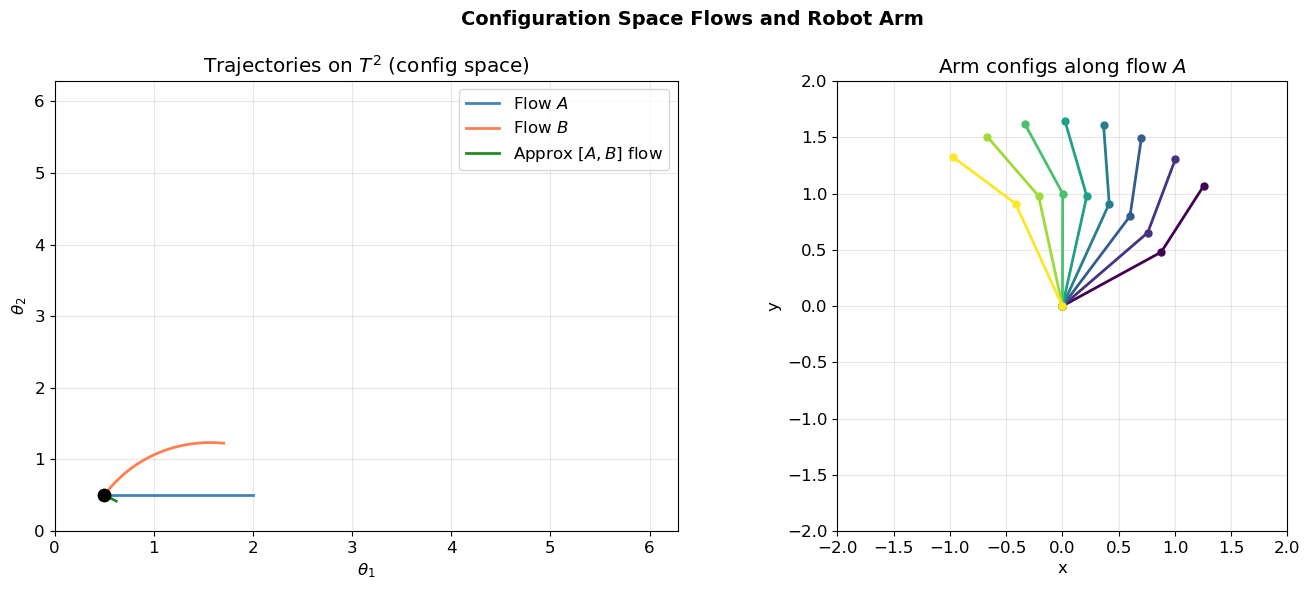

In [19]:
# ---- Visualise Flow on T² and Corresponding Arm Motion ----

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Flow on T² (shown as square [0, 2pi]²)
ax = axes[0]
theta0 = np.array([0.5, 0.5])
dt_flow = 1.5

_, traj_A = compute_flow(field_A, theta0, [0, dt_flow], 300)
_, traj_B = compute_flow(field_B, theta0, [0, dt_flow], 300)

# Approximate [A,B] flow via iterated commutator brackets
eps_bracket = 0.05
p_bracket = theta0.copy()
bracket_traj = [p_bracket.copy()]
for _ in range(60):
    _, tr1 = compute_flow(field_A, p_bracket, [0, eps_bracket], 10)
    p_bracket = tr1[-1]
    _, tr2 = compute_flow(field_B, p_bracket, [0, eps_bracket], 10)
    p_bracket = tr2[-1]
    _, tr3 = compute_flow(field_A, p_bracket, [0, -eps_bracket], 10)
    p_bracket = tr3[-1]
    _, tr4 = compute_flow(field_B, p_bracket, [0, -eps_bracket], 10)
    p_bracket = tr4[-1]
    bracket_traj.append(p_bracket.copy())
bracket_traj = np.array(bracket_traj)

ax.plot(traj_A[:,0] % (2*np.pi), traj_A[:,1] % (2*np.pi), 'steelblue', linewidth=2, label='Flow $A$')
ax.plot(traj_B[:,0] % (2*np.pi), traj_B[:,1] % (2*np.pi), 'coral', linewidth=2, label='Flow $B$')
ax.plot(bracket_traj[:,0] % (2*np.pi), bracket_traj[:,1] % (2*np.pi),
        'forestgreen', linewidth=2, label='Approx $[A,B]$ flow')
ax.scatter(*theta0, color='black', s=80, zorder=5)
ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('$\\theta_2$')
ax.set_title('Trajectories on $T^2$ (config space)')
ax.set_xlim(0, 2*np.pi); ax.set_ylim(0, 2*np.pi)
ax.legend()

# Arm configurations along flow A trajectory
ax = axes[1]
L1, L2 = 1.0, 0.7
n_configs = 8
idx_configs = np.linspace(0, len(traj_A)-1, n_configs, dtype=int)
cmap_arm = plt.cm.viridis(np.linspace(0, 1, n_configs))
for i, idx in enumerate(idx_configs):
    th = traj_A[idx]
    x1 = L1*np.cos(th[0])
    y1 = L1*np.sin(th[0])
    x2, y2 = forward_kinematics_2link(th)
    ax.plot([0, x1, x2], [0, y1, y2], 'o-', color=cmap_arm[i], markersize=5, linewidth=2)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Arm configs along flow $A$')
ax.set_aspect('equal')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

plt.suptitle('Configuration Space Flows and Robot Arm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Summary

| Concept | Computation | Key Function |
|---------|-------------|-------------|
| Chart / Atlas | Coordinate maps, transition maps | `stereo_north`, `transition_NS` |
| Tangent vector | Curve velocity in chart coords | `tangent_vector_via_curve` |
| Chart transition of vectors | Jacobian of transition map | `transition_NS_jacobian` |
| Differential (pushforward) | Numerical Jacobian | `compute_pushforward`, `pushforward_matrix` |
| Vector field | Function $p \mapsto T_pM$ | `sphere_field_z_rotation`, etc. |
| Flow | ODE integration (`solve_ivp`) | `compute_flow`, `compute_flow_on_sphere` |
| Lie bracket | Jacobian formula $DY \cdot X - DX \cdot Y$ | `lie_bracket_numerical` |
| Submanifold (level set) | Regular value theorem + SVD kernel | `tangent_space_kernel` |
| Controllability | Lie algebra rank condition | Chow's theorem application |

### Cross-References

- **Lie Groups notebook** (`lie-groups/`): The exponential map $\exp: \mathfrak{g} \to G$ is the time-1 flow of a left-invariant vector field — Section 4 here explains *why* this works.
- **Differential Geometry notebook** (`differential-geometry/`): Christoffel symbols and geodesics use chart coordinates from Section 1; curvature uses the pushforward from Section 3.
- **Matrix Manifolds notebook** (`matrix-manifolds/`): Tangent spaces via ambient projection (extrinsic) vs. the chart-based (intrinsic) approach in Section 2.

### Next Steps

The companion notebook **Calculus on Manifolds** builds on these foundations to develop
differential forms, the exterior derivative, integration on manifolds, and Stokes' theorem.